# 03 — Experimentos y evaluación final

Se comparan 12 configuraciones: Dummy, regresión logística, SVM, Random Forest y
XGBoost. Los dos últimos están sugeridos por el profesor. Gana el F1 macro medio
en validación cruzada; test no decide el ganador.

Este notebook muestra la ejecución guardada por `python -m src.models.train`.
Si no existe, la ejecuta. Para reproducir desde cero use ese comando; no cambie
hiperparámetros después de leer test para luego presentar ese mismo test como nuevo.


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "README.profe").exists():
    ROOT = ROOT.parent
if not (ROOT / "README.profe").exists():
    raise RuntimeError("Abra Jupyter desde la raíz del proyecto")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd

from src.data.dataset import load_data, split_data

df = load_data()
X_train, X_test, y_train, y_test = split_data(df)
print("Entrenamiento:", X_train.shape, "Test reservado:", X_test.shape)

Entrenamiento: (1600, 20) Test reservado: (400, 20)


In [2]:
import json

from src.models.train import train

results = ROOT / "docs/results"
if not (results / "evaluation.json").exists():
    train()
evaluation = json.loads((results / "evaluation.json").read_text(encoding="utf-8"))
display(pd.read_csv(results / "leaderboard.csv"))
print("Modelo seleccionado por CV:", evaluation["winner"])
print("Parámetros:", evaluation["best_params"])

2026/09/06 02:36:37 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at C:\Users\catal\Documents\ChatGPT\Trabajo-Final-Aprendizaje 2\.venv\Lib\site-packages\mlflow\assistant\skills\instrumenting-with-mlflow-tracing\SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.


,model,cv_f1_macro,cv_f1_std,cv_accuracy,train_f1_macro,best_params
0,logistic_regression,0.963040,0.009183,0.963125,0.984667,"{""model__C"": 10}"
1,xgboost,0.904946,0.017602,0.905000,1.000000,"{""model__learning_rate"": 0.1, ""model__max_dept..."
2,random_forest,0.873746,0.032761,0.874375,1.000000,"{""model__max_depth"": 12, ""model__min_samples_l..."
3,svm,0.858545,0.009562,0.857500,0.983148,"{""model__C"": 1, ""model__gamma"": ""scale""}"
4,dummy,0.100000,0.000000,0.250000,0.100000,{}


Modelo seleccionado por CV: logistic_regression
Parámetros: {'model__C': 10}


## Test reservado
Son 400 ejemplos que no participaron en el ajuste. Las métricas describen este dataset, no una validación comercial externa.

test_accuracy             0.975000
test_f1_macro             0.975035
test_ordinal_mae          0.025000
test_quadratic_kappa      0.989980
test_severe_error_rate    0.000000
Name: valor, dtype: float64

,precision,recall,f1-score,support
0,0.989899,0.980,0.984925,100.000
1,0.979592,0.960,0.969697,100.000
2,0.951456,0.980,0.965517,100.000
3,0.980000,0.980,0.980000,100.000
accuracy,0.975000,0.975,0.975000,0.975
macro avg,0.975237,0.975,0.975035,400.000
weighted avg,0.975237,0.975,0.975035,400.000


Cumple metas académicas propuestas: True


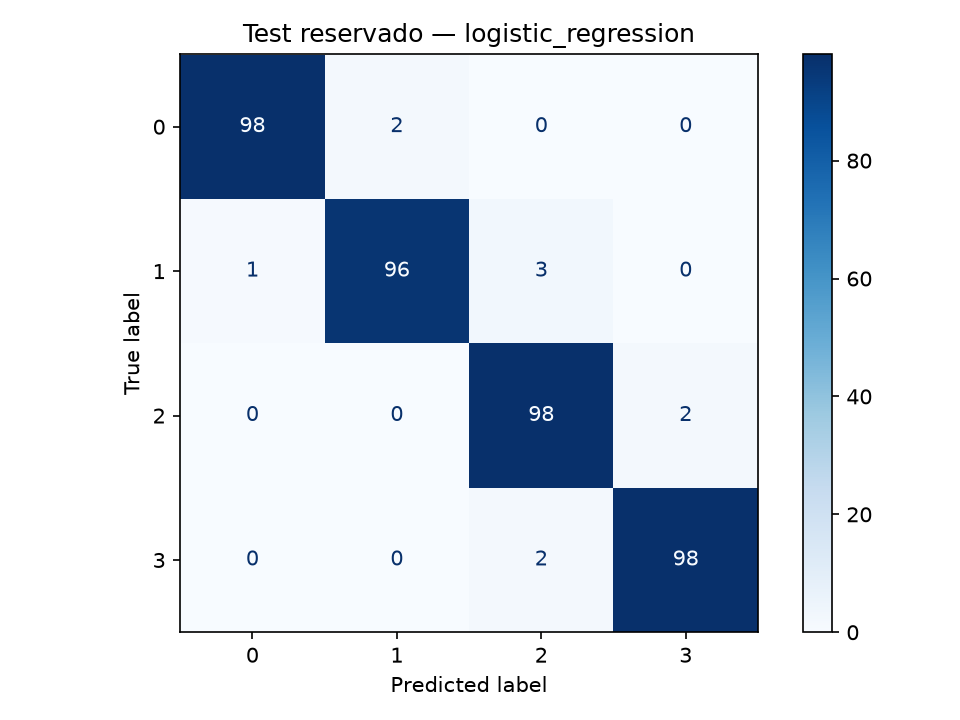

In [3]:
display(pd.Series(evaluation["metrics"], name="valor"))
display(pd.DataFrame(evaluation["classification_report"]).T)
print("Cumple metas académicas propuestas:", evaluation["acceptance_passed"])
from IPython.display import Image, display

display(Image(filename=str(results / "confusion_matrix.png")))

## Tracking y registro

La ejecución guarda parámetros, métricas y artefactos en MLflow local (`mlflow.db`).
Para abrirlo, desde la raíz ejecute:

```text
uv run mlflow ui --backend-store-uri sqlite:///mlflow.db --host 127.0.0.1 --port 5000
```

Abra http://127.0.0.1:5000. En el experimento `mobile-price-classification` verá
una ejecución por algoritmo y el CSV con todas sus configuraciones. El mejor pipeline
se registra como `mobile-price-classifier`; recibe alias `champion` si supera las metas.
La base y los modelos permanecen locales, mientras las métricas se publican en GitHub.

**Siguiente etapa:** explicar los errores, orquestar con Prefect y servir el pipeline
completo. No afirmar que Random Forest o XGBoost son mejores sin leer los resultados.
